# 02 — ERCOT Weather Integration and Demand-Risk EDA

This notebook builds a validated hourly weather-demand dataset for ERCOT forecasting. Historical weather from six representative Texas cities is aggregated to hourly Texas-level features and joined to the demand dataset using DuckDB SQL.

The EDA focuses weather conditions associated with high and extreme demand. The completed dataset will be used for weather-enhanced modeling in Notebook 03.

In [1]:
import numpy as np
import duckdb

con = duckdb.connect("ercot_weather.duckdb")
print(con.execute("SELECT 1 AS test").fetchdf())

   test
0     1


## Pull Historical Weather Data

Hourly historical weather was pulled from the Open-Meteo Historical Weather API for 2019 through 2025. Six Texas cities were selected to provide geographic coverage across major population centers and climate regions within the ERCOT market.

In [2]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": [29.7604, 32.7767, 30.2672, 29.4241, 27.8006, 31.9973],
    "longitude": [-95.3698, -96.797, -97.7431, -98.4936, -97.3964, -102.0779],
    "start_date": "2019-01-01",
    "end_date": "2025-12-31",
    "hourly": ["temperature_2m", "relative_humidity_2m", "dew_point_2m", "apparent_temperature", "precipitation",
               "cloud_cover", "wind_speed_10m", "weather_code"],
    "temperature_unit": "fahrenheit",
    "wind_speed_unit": "mph",
    "precipitation_unit": "inch",
}
responses = openmeteo.weather_api(url, params=params)

locations = [
    {'location_name': 'Houston', 'latitude': 29.7604, 'longitude': -95.3698},
    {'location_name': 'Dallas', 'latitude': 32.7767, 'longitude': -96.7970},
    {'location_name': 'Austin', 'latitude': 30.2672, 'longitude': -97.7431},
    {"location_name": "San Antonio", "latitude": 29.4241, "longitude": -98.4936},
    {"location_name": "Corpus Christi", "latitude": 27.8006, "longitude": -97.3964},
    {"location_name": "Midland", "latitude": 31.9973, "longitude": -102.0779},
]

weather_dfs = []

# Process 6 locations
for location, response in zip(locations, responses):
    print(f"\nCoordinates: {response.Latitude()}°N {response.Longitude()}°E")
    print(f"Elevation: {response.Elevation()} m asl")
    print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

    # Process hourly data. The order of variables needs to be the same as requested.
    hourly = response.Hourly()
    hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
    hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
    hourly_dew_point_2m = hourly.Variables(2).ValuesAsNumpy()
    hourly_apparent_temperature = hourly.Variables(3).ValuesAsNumpy()
    hourly_precipitation = hourly.Variables(4).ValuesAsNumpy()
    hourly_cloud_cover = hourly.Variables(5).ValuesAsNumpy()
    hourly_wind_speed_10m = hourly.Variables(6).ValuesAsNumpy()
    hourly_weather_code = hourly.Variables(7).ValuesAsNumpy()

    hourly_data = {
        'period_utc': pd.date_range(
            start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()),
            inclusive="left",
        ),
        'temperature_2m': hourly_temperature_2m,
        'relative_humidity_2m': hourly_relative_humidity_2m,
        'dew_point_2m': hourly_dew_point_2m,
        'apparent_temperature': hourly_apparent_temperature,
        'precipitation': hourly_precipitation,
        'cloud_cover': hourly_cloud_cover,
        'wind_speed_10m': hourly_wind_speed_10m,
        'weather_code': hourly_weather_code
    }

    hourly_df = pd.DataFrame(data=hourly_data)
    hourly_df["location_name"] = location["location_name"]
    hourly_df["latitude"] = location["latitude"]
    hourly_df["longitude"] = location["longitude"]
    weather_dfs.append(hourly_df)

df_all = pd.concat(weather_dfs, ignore_index=True)
df_all.shape


Coordinates: 29.771528244018555°N -95.33099365234375°E
Elevation: 20.0 m asl
Timezone difference to GMT+0: 0s

Coordinates: 32.794376373291016°N -96.82150268554688°E
Elevation: 137.0 m asl
Timezone difference to GMT+0: 0s

Coordinates: 30.26361846923828°N -97.69320678710938°E
Elevation: 157.0 m asl
Timezone difference to GMT+0: 0s

Coordinates: 29.420034408569336°N -98.52194213867188°E
Elevation: 203.0 m asl
Timezone difference to GMT+0: 0s

Coordinates: 27.732864379882812°N -97.38201904296875°E
Elevation: 8.0 m asl
Timezone difference to GMT+0: 0s

Coordinates: 32.021087646484375°N -102.0506591796875°E
Elevation: 851.0 m asl
Timezone difference to GMT+0: 0s


(368208, 12)

The weather pull produced 368,208 city-hour records: 61,368 hourly observations for each of the six selected cities.

## Validate city-level weather data

In [3]:
df_all.isna().sum()

period_utc              0
temperature_2m          0
relative_humidity_2m    0
dew_point_2m            0
apparent_temperature    0
precipitation           0
cloud_cover             0
wind_speed_10m          0
weather_code            0
location_name           0
latitude                0
longitude               0
dtype: int64

In [4]:
df_all[['location_name','latitude','longitude']].drop_duplicates().sort_values('location_name')

,location_name,latitude,longitude
122736,Austin,30.2672,-97.7431
245472,Corpus Christi,27.8006,-97.3964
61368,Dallas,32.7767,-96.7970
0,Houston,29.7604,-95.3698
306840,Midland,31.9973,-102.0779
184104,San Antonio,29.4241,-98.4936


In [5]:
df_all.groupby('location_name')[['latitude','longitude']].nunique()

,latitude,longitude
location_name,,
Austin,1,1
Corpus Christi,1,1
Dallas,1,1
Houston,1,1
Midland,1,1
San Antonio,1,1


In [6]:
df_all.drop(columns = ['latitude','longitude'],inplace=True)

In [7]:
df_all['period_utc'].min(), df_all['period_utc'].max()

(Timestamp('2019-01-01 00:00:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:00:00+0000', tz='UTC'))

In [8]:
df_all.duplicated().sum()

np.int64(0)

In [9]:
df_all['location_name'].value_counts()

location_name
Houston           61368
Dallas            61368
Austin            61368
San Antonio       61368
Corpus Christi    61368
Midland           61368
Name: count, dtype: int64

In [10]:
hour_counts = df_all['period_utc'].value_counts()
hour_counts[hour_counts>6]  , hour_counts[hour_counts<6]

(Series([], Name: count, dtype: int64), Series([], Name: count, dtype: int64))

In [11]:
city_hour_counts = df_all.groupby(['period_utc', 'location_name']).size()
city_hour_counts.value_counts()

1    368208
Name: count, dtype: int64

In [12]:
df_all.dtypes

period_utc              datetime64[s, UTC]
temperature_2m                     float32
relative_humidity_2m               float32
dew_point_2m                       float32
apparent_temperature               float32
precipitation                      float32
cloud_cover                        float32
wind_speed_10m                     float32
weather_code                       float32
location_name                          str
dtype: object

In [13]:
assert df_all['relative_humidity_2m'].between(0,100).all()
assert df_all['cloud_cover'].between(0,100).all()
assert df_all['precipitation'].ge(0).all()
assert df_all['wind_speed_10m'].ge(0).all()
assert df_all['temperature_2m'].between(-20,130).all()
assert df_all['dew_point_2m'].between(-40,100).all()
assert df_all['apparent_temperature'].between(-40,140).all()

In [14]:
df_all['weather_code'].value_counts().sort_index()

weather_code
0.0     151387
1.0      41329
2.0      27315
3.0      97140
51.0     33840
53.0      6439
55.0      1788
61.0      3735
63.0      3784
65.0      1021
71.0       223
73.0       160
75.0        47
Name: count, dtype: int64

Weather codes were reviewed but were not included in the statewide dataset because they are categorical conditions that cannot be meaningfully averaged across cities. The related numeric weather measurements were retained instead.

The city-level weather data passed validation. All six cities contain 61,368 hourly observations covering 2019 through 2025, with no missing values or duplicate city-hour records. Every timestamp contains exactly six city observations, and the coordinates remain consistent within each city. Weather measurements also fall within plausible ranges and use the expected data types.

Latitude and longitude were removed after validating the city mappings because they are static location identifiers rather than hourly weather features. Weather codes were reviewed for valid categories but will not be averaged during statewide aggregation because they represent categorical conditions.

In [15]:
df_weather_statewide = (
    df_all.groupby('period_utc')
    .agg(
        temp_mean = ('temperature_2m', 'mean'),
        temp_max = ('temperature_2m', 'max'),
        temp_min = ('temperature_2m', 'min'),
        humid_mean = ('relative_humidity_2m', 'mean'),
        dewpoint_mean = ('dew_point_2m', 'mean'),
        cloud_cover_mean = ('cloud_cover', 'mean'),
        apparent_temp_mean = ('apparent_temperature', 'mean'),
        wind_speed_mean = ('wind_speed_10m', 'mean'),
        precip_mean = ('precipitation', 'mean')
    )
    .reset_index()
)

In [16]:
df_weather_statewide.shape, df_weather_statewide.head()

((61368, 10),
                  period_utc  temp_mean   temp_max   temp_min  humid_mean  \
 0 2019-01-01 00:00:00+00:00  53.028049  60.068302  49.549999   66.354027   
 1 2019-01-01 01:00:00+00:00  50.313049  54.488300  44.959999   72.637932   
 2 2019-01-01 02:00:00+00:00  48.423050  56.918301  40.910000   77.716431   
 3 2019-01-01 03:00:00+00:00  46.713055  55.028301  39.740002   80.421806   
 4 2019-01-01 04:00:00+00:00  46.353046  53.588299  39.829998   79.274696   
 
    dewpoint_mean  cloud_cover_mean  apparent_temp_mean  wind_speed_mean  \
 0      41.328049         75.500000           49.174847         4.485577   
 1      41.613049         68.500000           46.497345         4.511508   
 2      41.613049         69.833336           44.354187         5.153232   
 3      40.863049         43.333332           42.663456         4.713463   
 4      40.083050         28.666666           41.837082         5.404507   
 
    precip_mean  
 0          0.0  
 1          0.0  
 2        

## Build Hourly Texas Weather Features

City-level observations are aggregated by `period_utc` to create one weather record per hour. Mean values summarize conditions across the six cities, while minimum and maximum temperatures preserve the geographic temperature spread that would be lost by using only the average.

In [17]:
df_weather_statewide.duplicated(subset="period_utc").sum()

np.int64(0)

In [18]:
df_weather_statewide.isna().sum()

period_utc            0
temp_mean             0
temp_max              0
temp_min              0
humid_mean            0
dewpoint_mean         0
cloud_cover_mean      0
apparent_temp_mean    0
wind_speed_mean       0
precip_mean           0
dtype: int64

In [19]:
df_weather_statewide['period_utc'].min(), df_weather_statewide['period_utc'].max()

(Timestamp('2019-01-01 00:00:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:00:00+0000', tz='UTC'))

In [20]:
df_weather_statewide.describe()

,temp_mean,temp_max,temp_min,humid_mean,dewpoint_mean,cloud_cover_mean,apparent_temp_mean,wind_speed_mean,precip_mean
count,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000
mean,69.859177,75.736641,63.567463,66.259727,56.149075,47.159454,69.842133,8.816807,0.005014
std,14.774034,13.387877,16.355965,16.612421,14.260589,30.894894,18.836140,3.286971,0.015541
min,11.058051,20.558300,-1.930000,10.465085,-8.366949,0.000000,-1.202997,1.532981,0.000000
25%,59.883053,67.279999,51.440002,53.884518,46.304298,19.500000,56.383151,6.330686,0.000000
50%,71.883049,77.258301,66.199997,67.539360,59.988049,46.666668,72.533203,8.289782,0.000000
75%,80.838051,84.650002,76.910004,79.791765,67.983055,73.666664,85.215422,10.832446,0.001969
max,103.233055,111.199997,94.358299,98.822609,76.143044,100.000000,107.610176,24.943560,0.347113


The aggregation produced 61,368 unique hourly weather records covering 2019 through 2025. The table contains no missing values or duplicate timestamps, and the weather-feature ranges remain plausible after aggregation. It is now structured at the same hourly grain as the ERCOT demand data and is ready for the SQL join.

In [21]:
from pathlib import Path

data_dir = Path("C:/Users/jfreeman-chambless/Downloads")

df_demand = pd.read_csv(data_dir / 'demand_hourly.csv', parse_dates=['period_utc'])


Importing the demand dataset to later join using SQL.

In [22]:
df_demand.head()

,period_utc,value,hour,dayofweek,month,year,lag_1,lag_24,lag_168,rolling_mean_24,rolling_mean_168,high_demand_flag,extreme_demand_flag
0,2019-01-01 06:00:00+00:00,37301.0,6,1,1,2019,NaN,NaN,NaN,NaN,NaN,False,False
1,2019-01-01 07:00:00+00:00,36953.0,7,1,1,2019,37301.0,NaN,NaN,NaN,NaN,False,False
2,2019-01-01 08:00:00+00:00,37114.0,8,1,1,2019,36953.0,NaN,NaN,NaN,NaN,False,False
3,2019-01-01 09:00:00+00:00,37154.0,9,1,1,2019,37114.0,NaN,NaN,NaN,NaN,False,False
4,2019-01-01 10:00:00+00:00,37290.0,10,1,1,2019,37154.0,NaN,NaN,NaN,NaN,False,False


In [23]:
df_demand.dtypes, df_weather_statewide.dtypes

(period_utc             datetime64[us, UTC]
 value                              float64
 hour                                 int64
 dayofweek                            int64
 month                                int64
 year                                 int64
 lag_1                              float64
 lag_24                             float64
 lag_168                            float64
 rolling_mean_24                    float64
 rolling_mean_168                   float64
 high_demand_flag                      bool
 extreme_demand_flag                   bool
 dtype: object,
 period_utc            datetime64[s, UTC]
 temp_mean                        float32
 temp_max                         float32
 temp_min                         float32
 humid_mean                       float32
 dewpoint_mean                    float32
 cloud_cover_mean                 float32
 apparent_temp_mean               float32
 wind_speed_mean                  float32
 precip_mean                      

Looking at datatypes in both dataframes.

In [24]:
df_demand['period_utc'] = pd.to_datetime(df_demand['period_utc'],utc = True).dt.floor('h')
df_weather_statewide['period_utc'] = pd.to_datetime(df_weather_statewide['period_utc'],utc = True).dt.floor('h')

In [25]:
df_demand['period_utc'].head()

0   2019-01-01 06:00:00+00:00
1   2019-01-01 07:00:00+00:00
2   2019-01-01 08:00:00+00:00
3   2019-01-01 09:00:00+00:00
4   2019-01-01 10:00:00+00:00
Name: period_utc, dtype: datetime64[us, UTC]

Ensuring the timeframes in both datasets will work.

## Join Demand and Weather with DuckDB

In [26]:
con.execute('''
    CREATE OR REPLACE TABLE demand AS
    SELECT *
    FROM df_demand''')

In [27]:
con.execute('''
    CREATE OR REPLACE TABLE weather AS
    SELECT *
    FROM df_weather_statewide''')

In [28]:
con.sql('SHOW TABLES;').show()

┌──────────────────────┐
│         name         │
│       varchar        │
├──────────────────────┤
│ demand               │
│ demand_weather_model │
│ weather              │
└──────────────────────┘



In [29]:
con.sql('SHOW weather;').show()

┌────────────────────┬──────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│    column_name     │       column_type        │  null   │   key   │ default │  extra  │
│      varchar       │         varchar          │ varchar │ varchar │ varchar │ varchar │
├────────────────────┼──────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ period_utc         │ TIMESTAMP WITH TIME ZONE │ YES     │ NULL    │ NULL    │ NULL    │
│ temp_mean          │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ temp_max           │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ temp_min           │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ humid_mean         │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ dewpoint_mean      │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ cloud_cover_mean   │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ apparent

In [30]:
con.sql('SHOW demand;').show()

┌─────────────────────┬──────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name     │       column_type        │  null   │   key   │ default │  extra  │
│       varchar       │         varchar          │ varchar │ varchar │ varchar │ varchar │
├─────────────────────┼──────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ period_utc          │ TIMESTAMP WITH TIME ZONE │ YES     │ NULL    │ NULL    │ NULL    │
│ value               │ DOUBLE                   │ YES     │ NULL    │ NULL    │ NULL    │
│ hour                │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ dayofweek           │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ month               │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ year                │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ lag_1               │ DOUBLE                   │ YES     │ NULL    │ NULL    │ NULL    │

In [31]:
con.sql('''SELECT
            COUNT(*) AS row_count,
            COUNT(DISTINCT period_utc) AS distinct_hours,
            COUNT(*) - COUNT(DISTINCT period_utc) AS duplicate_hours,
            MIN(period_utc) AS min_period_utc,
            MAX(period_utc) AS max_period_utc
            FROM demand;''')

┌───────────┬────────────────┬─────────────────┬──────────────────────────┬──────────────────────────┐
│ row_count │ distinct_hours │ duplicate_hours │      min_period_utc      │      max_period_utc      │
│   int64   │     int64      │      int64      │ timestamp with time zone │ timestamp with time zone │
├───────────┼────────────────┼─────────────────┼──────────────────────────┼──────────────────────────┤
│     61345 │          61345 │               0 │ 2019-01-01 00:00:00-06   │ 2025-12-31 00:00:00-06   │
└───────────┴────────────────┴─────────────────┴──────────────────────────┴──────────────────────────┘

In [32]:
con.sql('''SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT period_utc) AS distinct_hours,
    COUNT(*) - COUNT(DISTINCT period_utc) AS duplicate_hours,
    MIN(period_utc) AS min_period_utc,
    MAX(period_utc) AS max_period_utc
FROM weather;''')

┌───────────┬────────────────┬─────────────────┬──────────────────────────┬──────────────────────────┐
│ row_count │ distinct_hours │ duplicate_hours │      min_period_utc      │      max_period_utc      │
│   int64   │     int64      │      int64      │ timestamp with time zone │ timestamp with time zone │
├───────────┼────────────────┼─────────────────┼──────────────────────────┼──────────────────────────┤
│     61368 │          61368 │               0 │ 2018-12-31 18:00:00-06   │ 2025-12-31 17:00:00-06   │
└───────────┴────────────────┴─────────────────┴──────────────────────────┴──────────────────────────┘

Both tables were validated at one row per hour before joining. Demand is used as the left table because it contains the forecasting target, so the result should retain every available demand hour even though the weather table covers additional hours.

In [33]:
con.sql('''CREATE OR REPLACE TABLE demand_weather_model AS
       SELECT
           d.*,

           w.temp_mean,
           w.temp_max,
           w.temp_min,
           w.humid_mean,
           w.dewpoint_mean,
           w.cloud_cover_mean,
           w.apparent_temp_mean,
           w.wind_speed_mean,
           w.precip_mean

FROM demand AS d
LEFT JOIN weather as w
    ON d.period_utc = w.period_utc;''')

In [34]:
con.sql('SHOW TABLES;').show()

┌──────────────────────┐
│         name         │
│       varchar        │
├──────────────────────┤
│ demand               │
│ demand_weather_model │
│ weather              │
└──────────────────────┘



In [35]:
con.sql('SHOW demand_weather_model;')

┌─────────────────────┬──────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name     │       column_type        │  null   │   key   │ default │  extra  │
│       varchar       │         varchar          │ varchar │ varchar │ varchar │ varchar │
├─────────────────────┼──────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ period_utc          │ TIMESTAMP WITH TIME ZONE │ YES     │ NULL    │ NULL    │ NULL    │
│ value               │ DOUBLE                   │ YES     │ NULL    │ NULL    │ NULL    │
│ hour                │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ dayofweek           │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ month               │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ year                │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ lag_1               │ DOUBLE                   │ YES     │ NULL    │ NULL    │ NULL    │

Joined the tables and ensuring all features were included.

In [36]:
con.sql('''SELECT
    (SELECT COUNT(*) FROM demand) AS demand_rows,
    (SELECT COUNT(*) FROM demand_weather_model) AS joined_rows,
    (SELECT COUNT(*) FROM demand) - (SELECT COUNT(*) FROM demand_weather_model) AS rows_difference;''')

┌─────────────┬─────────────┬─────────────────┐
│ demand_rows │ joined_rows │ rows_difference │
│    int64    │    int64    │      int64      │
├─────────────┼─────────────┼─────────────────┤
│       61345 │       61345 │               0 │
└─────────────┴─────────────┴─────────────────┘

In [37]:
con.sql('''SELECT
    SUM(CASE WHEN temp_mean IS NULL THEN 1 ELSE 0 END) AS missing_temp_mean,
    SUM(CASE WHEN temp_min IS NULL THEN 1 ELSE 0 END) AS mising_temp_min,
    SUM(CASE WHEN temp_max IS NULL THEN 1 ELSE 0 END) AS missing_temp_max,
    SUM(CASE WHEN humid_mean IS NULL THEN 1 ELSE 0 END) AS missing_humid_mean,
    SUM(CASE WHEN dewpoint_mean IS NULL THEN 1 ELSE 0 END) AS missing_dewpoint_mean,
    SUM(CASE WHEN cloud_cover_mean IS NULL THEN 1 ELSE 0 END) AS missing_cloud_cover_mean,
    SUM(CASE WHEN apparent_temp_mean IS NULL THEN 1 ELSE 0 END) AS missing_apparent_temp_mean,
    SUM(CASE WHEN wind_speed_mean IS NULL THEN 1 ELSE 0 END) AS missing_wind_speed_mean,
    SUM(CASE WHEN precip_mean IS NULL THEN 1 ELSE 0 END) AS missing_precip_mean
FROM demand_weather_model;''').show()

┌───────────────────┬─────────────────┬──────────────────┬────────────────────┬───────────────────────┬──────────────────────────┬────────────────────────────┬─────────────────────────┬─────────────────────┐
│ missing_temp_mean │ mising_temp_min │ missing_temp_max │ missing_humid_mean │ missing_dewpoint_mean │ missing_cloud_cover_mean │ missing_apparent_temp_mean │ missing_wind_speed_mean │ missing_precip_mean │
│      int128       │     int128      │      int128      │       int128       │        int128         │          int128          │           int128           │         int128          │       int128        │
├───────────────────┼─────────────────┼──────────────────┼────────────────────┼───────────────────────┼──────────────────────────┼────────────────────────────┼─────────────────────────┼─────────────────────┤
│                 0 │               0 │                0 │                  0 │                     0 │                        0 │                          0 │         

The demand table contains 61,345 unique hourly records, while the weather table contains 61,368. The additional weather hours fall outside the available demand period. The left join retained all 61,345 demand records without creating duplicate hours or missing weather matches.

The joined table includes the original demand, calendar, lag, rolling, and demand-segment fields along with nine aggregated weather features.

In [38]:
df_model = con.sql('''
        SELECT *
        FROM demand_weather_model
        ORDER BY period_utc;''').df()

In [39]:
con.close()

## Validate the Modeling Table

In [40]:
df_model.head()

,period_utc,value,hour,dayofweek,month,year,lag_1,lag_24,lag_168,rolling_mean_24,...,extreme_demand_flag,temp_mean,temp_max,temp_min,humid_mean,dewpoint_mean,cloud_cover_mean,apparent_temp_mean,wind_speed_mean,precip_mean
0,2019-01-01 00:00:00-06:00,37301.0,6,1,1,2019,NaN,NaN,NaN,NaN,...,False,44.088047,54.128300,37.580002,83.323517,39.213051,20.166666,39.003639,6.370968,0.0
1,2019-01-01 01:00:00-06:00,36953.0,7,1,1,2019,37301.0,NaN,NaN,NaN,...,False,42.678051,55.478302,34.340000,87.261353,39.078049,31.833334,37.659748,6.213417,0.0
2,2019-01-01 02:00:00-06:00,37114.0,8,1,1,2019,36953.0,NaN,NaN,NaN,...,False,41.748051,56.918301,31.280001,90.389404,39.093052,28.500000,36.578342,6.587480,0.0
3,2019-01-01 03:00:00-06:00,37154.0,9,1,1,2019,37114.0,NaN,NaN,NaN,...,False,40.833050,50.888298,28.940001,88.685234,37.683048,27.833334,34.419422,8.797850,0.0
4,2019-01-01 04:00:00-06:00,37290.0,10,1,1,2019,37154.0,NaN,NaN,NaN,...,False,40.158051,52.868301,27.410000,86.765106,36.423050,11.500000,33.537193,8.912553,0.0


In [41]:
df_model.tail()

,period_utc,value,hour,dayofweek,month,year,lag_1,lag_24,lag_168,rolling_mean_24,...,extreme_demand_flag,temp_mean,temp_max,temp_min,humid_mean,dewpoint_mean,cloud_cover_mean,apparent_temp_mean,wind_speed_mean,precip_mean
61340,2025-12-30 20:00:00-06:00,55192.0,2,2,12,2025,54666.0,59306.0,53744.0,54493.166667,...,False,47.733051,51.248299,43.700001,43.332798,25.803049,25.000000,41.399780,4.160393,0.0
61341,2025-12-30 21:00:00-06:00,55664.0,3,2,12,2025,55192.0,58882.0,53187.0,54321.750000,...,False,46.773052,50.978302,42.709999,44.582981,25.608049,28.666666,40.498539,3.954894,0.0
61342,2025-12-30 22:00:00-06:00,55464.0,4,2,12,2025,55664.0,57707.0,52244.0,54187.666667,...,False,45.738049,50.348297,41.720001,46.461666,25.623049,48.333332,39.659985,3.488230,0.0
61343,2025-12-30 23:00:00-06:00,54362.0,5,2,12,2025,55464.0,55839.0,50608.0,54094.208333,...,False,44.718048,48.638298,39.920002,48.826183,25.698050,45.000000,38.769230,3.217858,0.0
61344,2025-12-31 00:00:00-06:00,53189.0,6,2,12,2025,54362.0,54079.0,48432.0,54032.666667,...,False,42.213051,47.288300,36.860001,55.994694,27.003050,46.833332,36.559383,2.881998,0.0


In [42]:
df_model.shape

(61345, 22)

In [43]:
df_model.isna().sum()

period_utc               0
value                    0
hour                     0
dayofweek                0
month                    0
year                     0
lag_1                    1
lag_24                  24
lag_168                168
rolling_mean_24         24
rolling_mean_168       168
high_demand_flag         0
extreme_demand_flag      0
temp_mean                0
temp_max                 0
temp_min                 0
humid_mean               0
dewpoint_mean            0
cloud_cover_mean         0
apparent_temp_mean       0
wind_speed_mean          0
precip_mean              0
dtype: int64

Creating new dataframe from the database and validating.

In [44]:
df_model["period_utc"] = df_model["period_utc"].dt.tz_convert("UTC")
df_model.dtypes

period_utc             datetime64[us, UTC]
value                              float64
hour                                 int64
dayofweek                            int64
month                                int64
year                                 int64
lag_1                              float64
lag_24                             float64
lag_168                            float64
rolling_mean_24                    float64
rolling_mean_168                   float64
high_demand_flag                      bool
extreme_demand_flag                   bool
temp_mean                          float32
temp_max                           float32
temp_min                           float32
humid_mean                         float32
dewpoint_mean                      float32
cloud_cover_mean                   float32
apparent_temp_mean                 float32
wind_speed_mean                    float32
precip_mean                        float32
dtype: object

In [45]:
print(df_model.duplicated(subset=['period_utc']).sum())

0


In [46]:
is_sorted = df_model['period_utc'].is_monotonic_increasing
print ('Sorted by period_utc:', is_sorted)

Sorted by period_utc: True


In [47]:
non_hourly_gaps = df_model.loc[df_model['period_utc'].diff() != pd.Timedelta(hours=1), ['period_utc']]
non_hourly_gaps

,period_utc
0,2019-01-01 06:00:00+00:00


First row so not an actual gap.

In [48]:
range_checks = {
    "negative_demand": (df_model["value"] < 0).sum(),
    "humidity_below_0": (df_model["humid_mean"] < 0).sum(),
    "humidity_above_100": (df_model["humid_mean"] > 100).sum(),
    "cloud_cover_below_0": (df_model["cloud_cover_mean"] < 0).sum(),
    "cloud_cover_above_100": (df_model["cloud_cover_mean"] > 100).sum(),
    "negative_wind_speed": (df_model["wind_speed_mean"] < 0).sum(),
    "negative_precip": (df_model["precip_mean"] < 0).sum(),
    "temp_min_gt_temp_max": (df_model["temp_min"] > df_model["temp_max"]).sum(),
}

range_checks

{'negative_demand': np.int64(0),
 'humidity_below_0': np.int64(0),
 'humidity_above_100': np.int64(0),
 'cloud_cover_below_0': np.int64(0),
 'cloud_cover_above_100': np.int64(0),
 'negative_wind_speed': np.int64(0),
 'negative_precip': np.int64(0),
 'temp_min_gt_temp_max': np.int64(0)}

The joined modeling table contains 61,345 hourly records and 22 columns. Timestamps are unique, chronologically ordered, and continuous, and the demand and weather values pass the range checks.

Missing values are limited to the first observations of the lag and rolling-demand features. These are expected because the features require prior demand history. These initial rows will be handled before modeling. The target, calendar fields, demand-segment flags, and joined weather features contain no missing values.

## Analyze Weather-Related Demand Risk

The joined dataset is analyzed in Central Time so hourly patterns match ERCOT operating conditions. Demand segments are used only to describe high-risk periods and will not be included as model features.

In [49]:
#Convering to local for easy interpretation
df_model_eda = df_model.copy()

df_model_eda['period_local'] = df_model_eda['period_utc'].dt.tz_convert('America/Chicago')

df_model_eda['local_hour'] = df_model_eda['period_local'].dt.hour

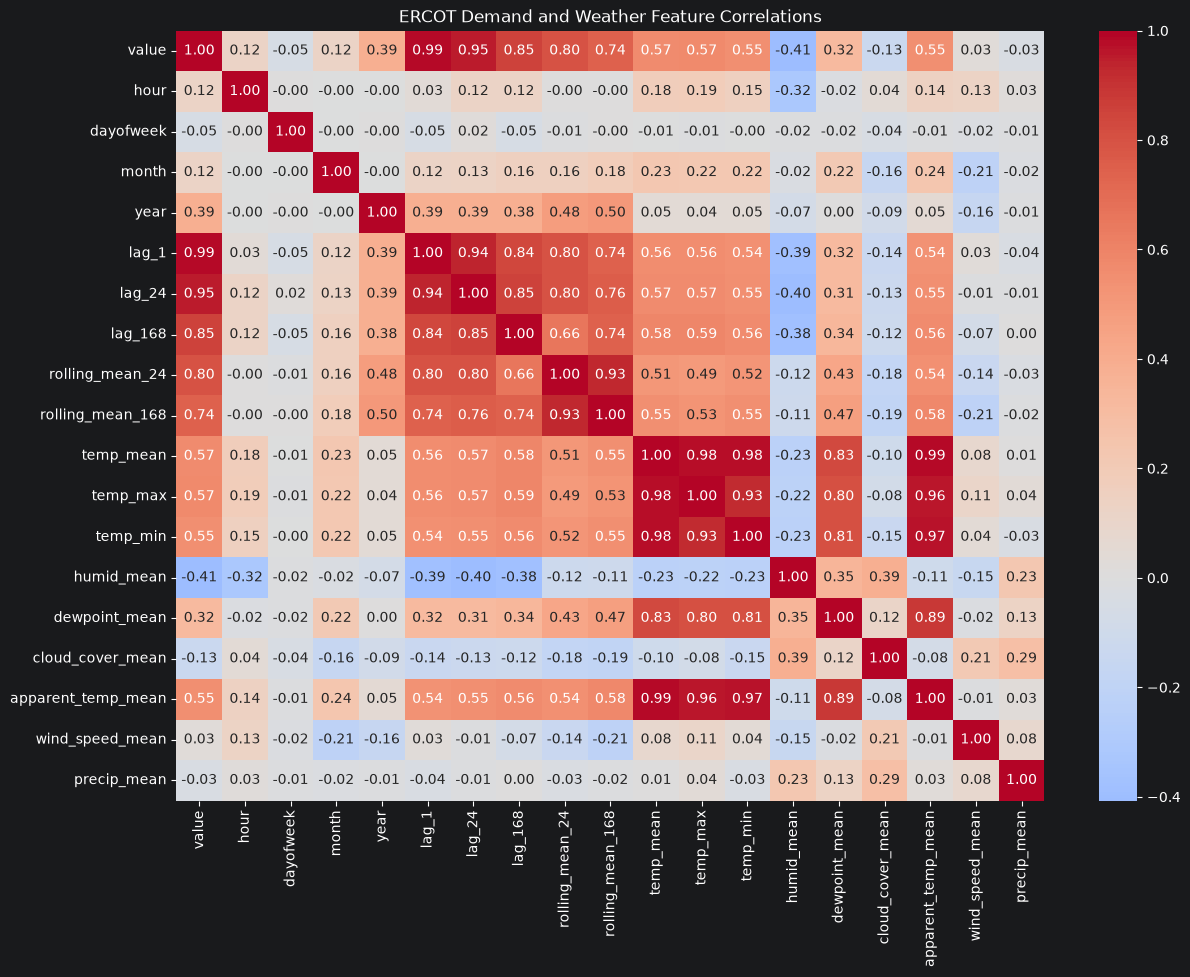

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = [
    "value",
    "hour",
    "dayofweek",
    "month",
    "year",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_mean_24",
    "rolling_mean_168",
    "temp_mean",
    "temp_max",
    "temp_min",
    "humid_mean",
    "dewpoint_mean",
    "cloud_cover_mean",
    "apparent_temp_mean",
    "wind_speed_mean",
    "precip_mean"
]

corr_matrix = df_model_eda[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title("ERCOT Demand and Weather Feature Correlations")
plt.show()

Demand-history features have the strongest linear relationships with the target, which is expected because electricity demand is highly autocorrelated. Temperature-based features also show an association with demand and are strongly correlated with one another, indicating that they capture overlapping weather information.

Pearson correlation also only measures linear relationships. It may understate the importance of temperature because demand can increase during both hot and cold conditions. Correlations for hour, day of week, and month are low as they are cyclical and this does not fit with a linear assocation. The following analysis examines these relationships directly rather than relying on correlation alone.

## High-Demand Risk by Time of Day

In [52]:
#Creating demand segment to highlight high risk instances
df_model_eda['demand_segment'] = np.select(
    [
        df_model_eda['extreme_demand_flag'] == True,
        df_model_eda['high_demand_flag'] == True
    ],
    [
        'extreme_p99_plus',
        'high_95_plus'
    ],
    default='normal'
)
df_model_eda['demand_segment'].value_counts()


demand_segment
normal              58276
high_95_plus         2455
extreme_p99_plus      614
Name: count, dtype: int64

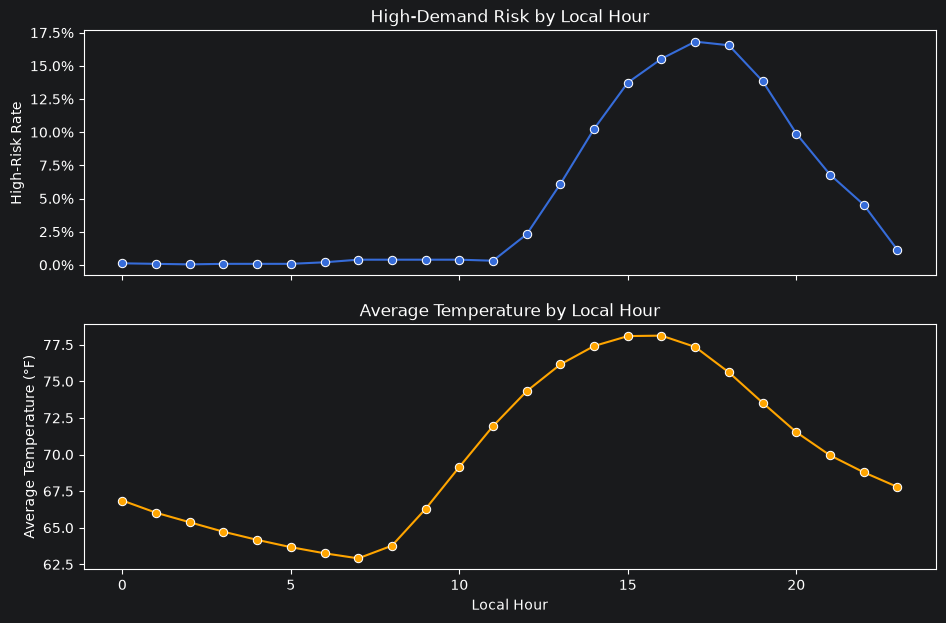

In [53]:
from matplotlib.ticker import PercentFormatter

hourly_risk = (
    df_model_eda.assign(is_high_risk=df_model_eda['demand_segment'] != 'normal')
    .groupby('local_hour')
    .agg(
        total_hours=('value', 'count'),
        high_risk_hours=('is_high_risk', 'sum'),
        mean_temp=('temp_mean','mean'),
        mean_demand=('value','mean')
    )
    .reset_index()
)
hourly_risk['high_risk_rate'] = hourly_risk['high_risk_hours'] / hourly_risk['total_hours']

fig,axes = plt.subplots(2,1,figsize=(11,7), sharex=True)

sns.lineplot(
    data = hourly_risk,
    x='local_hour',
    y='high_risk_rate',
    marker='o',
    ax=axes[0]
)
axes[0].set_title('High-Demand Risk by Local Hour')
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_ylabel('High-Risk Rate')

sns.lineplot(
    data = hourly_risk,
    x='local_hour',
    y='mean_temp',
    marker='o',
    color='orange',
    ax=axes[1]
)
axes[1].set_title('Average Temperature by Local Hour')
axes[1].set_xlabel('Local Hour')
axes[1].set_ylabel('Average Temperature (°F)')

plt.show()

High-demand risk begins rising during the early afternoon, peaks around 5-6 p.m., and then declines through the evening. At the peak, approximately 17% of observations for that hour fall within the high or extreme demand segments.

Average temperature peaks slightly earlier in the afternoon, while demand risk remains elevated into the early evening. This pattern identifies the late-afternoon and early-evening period as the primary operational risk window, especially when high temperatures overlap with sustained cooling demand.

## Seasonal Demand Patterns

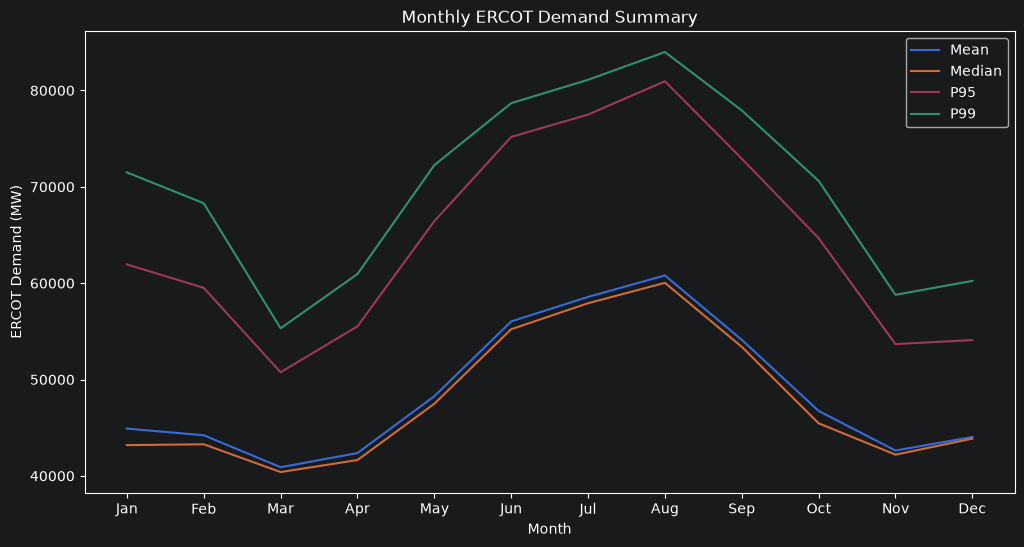

In [54]:
monthly_summary = (
    df_model_eda
    .groupby('month')
    .agg(
        mean_demand=('value', 'mean'),
        median_demand=('value', 'median'),
        p95_demand=('value', lambda x: x.quantile(0.95)),
        p99_demand=('value', lambda x: x.quantile(0.99))
    )
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_summary, x='month', y='mean_demand', label='Mean')
sns.lineplot(data=monthly_summary, x='month', y='median_demand', label='Median')
sns.lineplot(data=monthly_summary, x='month', y='p95_demand', label='P95')
sns.lineplot(data=monthly_summary, x='month', y='p99_demand', label='P99')
plt.title('Monthly ERCOT Demand Summary')
plt.xlabel('Month')
plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
plt.ylabel("ERCOT Demand (MW)")
plt.legend()
plt.show()

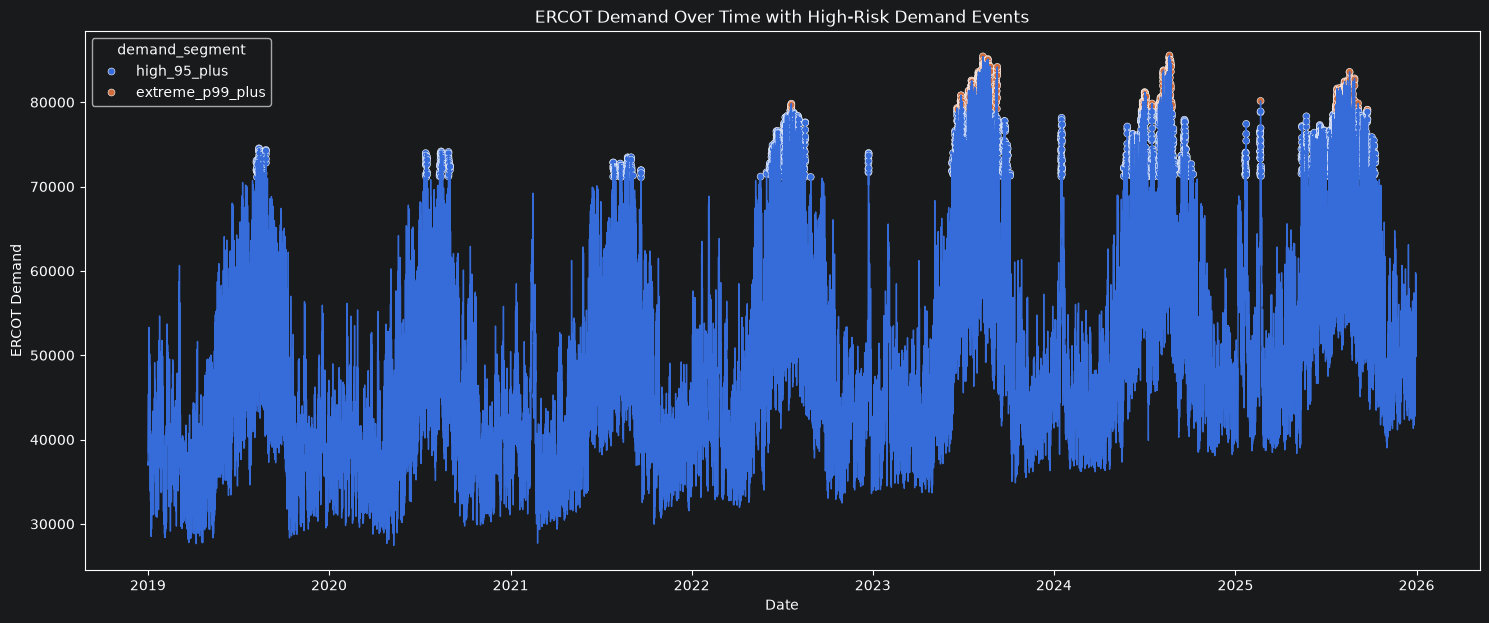

In [55]:
plt.figure(figsize=(18,7))

sns.lineplot(
    data=df_model_eda,
    x='period_utc',
    y='value',
    linewidth=1
)

sns.scatterplot(
    data=df_model_eda[df_model_eda['demand_segment']!='normal'],
    x='period_utc',
    y='value',
    hue='demand_segment',
    s=25
)

plt.title('ERCOT Demand Over Time with High-Risk Demand Events')
plt.xlabel('Date')
plt.ylabel('ERCOT Demand')
plt.show()

ERCOT demand follows a strong annual cycle. Typical demand is lowest during the mild spring months, rises sharply through the summer, and peaks in August. The P95 and P99 lines increase more sharply than the mean and median, showing that summer creates the greatest exposure to unusually high demand.

Winter demand is generally below summer levels, but its upper percentiles rise relative to fall and spring, indicating that cold-weather events can still create meaningful demand risk. The full time series confirms recurring summer high-demand clusters along with a broader increase in demand over time. Because the demand thresholds are fixed across the full period, the concentration of high-risk observations in recent years reflects both seasonal conditions and ERCOT demand growth.

## Temperature and Demand Risk

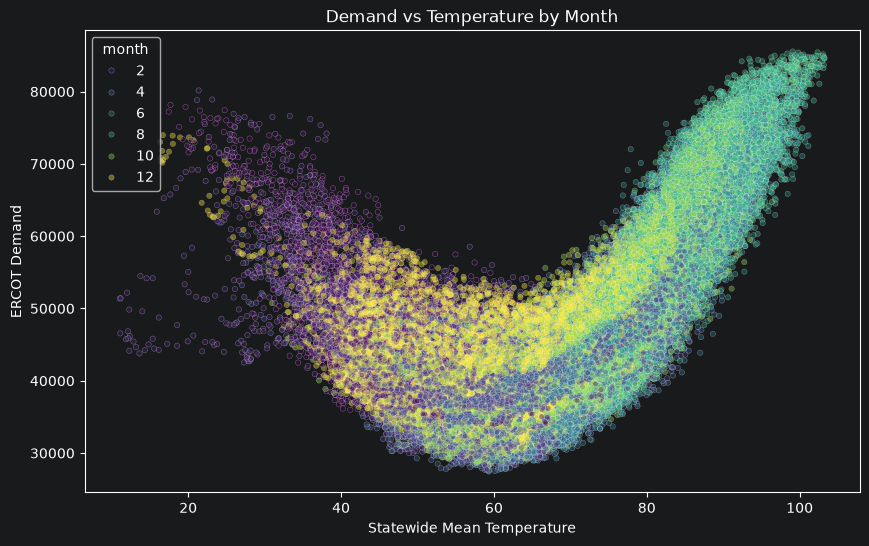

In [56]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_model_eda,
    x='temp_mean',
    y='value',
    hue='month',
    palette='viridis',
    alpha=.4,
    s=15
)
plt.title('Demand vs Temperature by Month')
plt.xlabel('Statewide Mean Temperature')
plt.ylabel('ERCOT Demand')
plt.show()

Text(0, 0.5, 'Texas Mean Temperature (°F)')

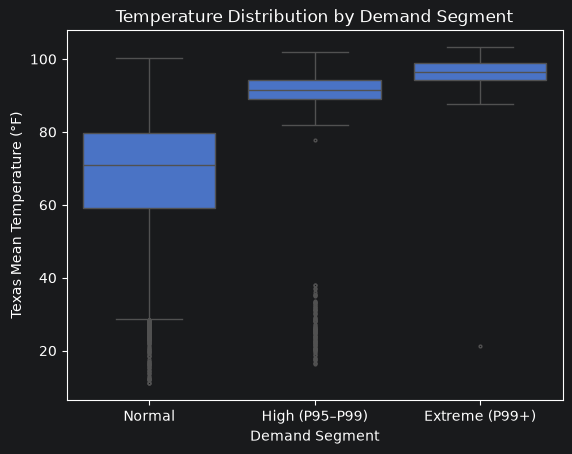

In [57]:
segment_order = ['normal', 'high_95_plus', 'extreme_p99_plus']

sns.boxplot(
    data=df_model_eda,
    x="demand_segment",
    y="temp_mean",
    order=segment_order,
    showfliers=True,
    fliersize=2
)

plt.xticks(
    [0, 1, 2],
    ["Normal", "High (P95–P99)", "Extreme (P99+)"]
)
plt.title("Temperature Distribution by Demand Segment")
plt.xlabel("Demand Segment")
plt.ylabel("Texas Mean Temperature (°F)")

The temperature-demand relationship is nonlinear. Demand is generally lower during mild conditions and rises at both cold and hot temperature extremes. The monthly coloring shows that the hot side of the relationship is associated primarily with summer, while the cold side is associated with winter conditions.

The demand-segment comparison shows that high and extreme demand hours are concentrated most consistently at high temperatures. A smaller number of high-demand hours also occur during severe cold. Overall, summer heat represents the most frequent weather-related demand risk, while extreme cold creates less common but still operationally important events.

## Temperature-Bin Analysis

In [58]:
df_model_eda["temp_bin"] = pd.cut(df_model_eda["temp_mean"], bins=15)
temp_bin_summary = (
    df_model_eda.groupby('temp_bin',observed=True).agg(
        mean_demand=('value','mean'),
        median_demand=('value','median'),
        hours=('value','count')
    )
    .reset_index()
)
temp_bin_summary

,temp_bin,mean_demand,median_demand,hours
0,"(10.966, 17.203]",54525.666667,49849.0,33
1,"(17.203, 23.348]",66607.149254,70749.0,67
2,"(23.348, 29.493]",61774.186441,63762.0,236
3,"(29.493, 35.638]",57084.891192,56841.0,579
4,"(35.638, 41.783]",50127.012625,49161.0,1505
5,"(41.783, 47.928]",44891.637876,44820.5,3126
6,"(47.928, 54.073]",41736.830543,41804.0,4420
7,"(54.073, 60.218]",39975.448922,39826.0,5707
8,"(60.218, 66.363]",39376.435808,39325.0,7423
9,"(66.363, 72.508]",41780.969801,41493.5,8444


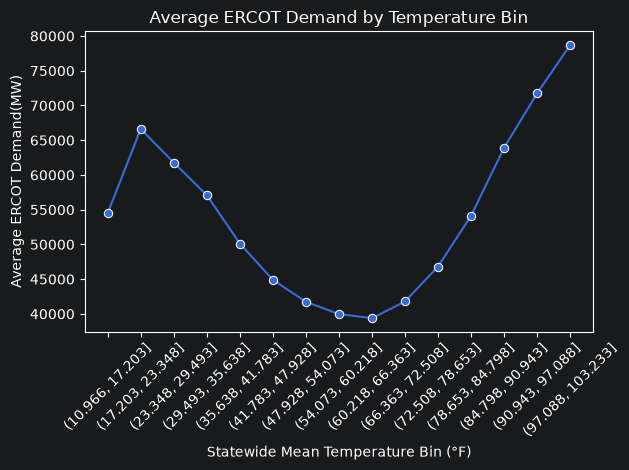

In [59]:
sns.lineplot(data=temp_bin_summary,
             x=temp_bin_summary['temp_bin'].astype(str),
             y='mean_demand',
             marker='o'
)
plt.title("Average ERCOT Demand by Temperature Bin")
plt.xlabel("Statewide Mean Temperature Bin (°F)")
plt.ylabel("Average ERCOT Demand(MW)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average demand follows a U-shaped temperature response. Demand is lowest during mild conditions around 55–65°F and increases as temperatures become hotter or colder. The coldest temperature bin breaks this pattern, with lower average demand than the next-coldest bin.

The coldest bin contains only 33 hours, compared with thousands of observations in the moderate-temperature bins. The underlying records were reviewed before interpreting this result as a typical extreme-cold demand pattern.

## Extreme-Cold Event Review

In [60]:
coldest_bin = temp_bin_summary.loc[0, "temp_bin"]
extreme_cold = df_model_eda.loc[
    df_model_eda['temp_bin'] == coldest_bin,
    ['period_local',
     'temp_mean',
     'value',
     'demand_segment']
]
extreme_cold

,period_local,temp_mean,value,demand_segment
18625,2021-02-15 01:00:00-06:00,16.803049,65255.0,normal
18626,2021-02-15 02:00:00-06:00,15.888050,63395.0,normal
18627,2021-02-15 03:00:00-06:00,15.363050,54178.0,normal
18628,2021-02-15 04:00:00-06:00,14.553050,54173.0,normal
18629,2021-02-15 05:00:00-06:00,13.743050,54504.0,normal
18630,2021-02-15 06:00:00-06:00,12.003049,52185.0,normal
18631,2021-02-15 07:00:00-06:00,11.058051,51388.0,normal
18632,2021-02-15 08:00:00-06:00,11.163051,51402.0,normal
18633,2021-02-15 09:00:00-06:00,12.288051,49849.0,normal
18634,2021-02-15 10:00:00-06:00,13.998051,49597.0,normal


The 33 observations in the coldest bin come from two weather events: February 15-16, 2021 and December 23, 2022.

Demand during the December 2022 observations remained around 70,000-74,000 MW. During the February 2021 event, recorded demand declined from approximately 65,000 MW into the mid-40,000 MW range as the event continued. This behavior is consistent with the effect of outages during the 2021 grid emergency rather than a normal reduction.

The 2021 observations represent a real operational event and should not automatically be removed. However, they require separate interpretation because recorded demand during a supply-constrained grid emergency may not represent the electricity demand that would have occurred without forced outages.

# Key Findings

- ERCOT demand follows a nonlinear temperature relationship, with lower demand during mild conditions and higher demand during hot and cold extremes.
- Summer heat is the most consistent weather condition associated with high and extreme demand.
- High-demand risk increases during the afternoon and peaks around 5–6 p.m., shortly after average temperature reaches its daily peak.
- Winter conditions create less frequent but still important demand risk. The February 2021 event requires separate interpretation because recorded demand was affected by grid constraints and load shedding.
- High-risk observations cluster by season and time of day, while the full-period analysis also shows that long-term demand growth contributes to the increasing number of recent high-demand hours.

Temperature is the clearest weather-related risk signal in this analysis. These findings can support resource planning, demand-response preparation, and reliability monitoring during high-risk weather and time windows.

# Modeling Handoff

The joined dataset is ready for weather-enhanced modeling in Notebook 03. The EDA indicates that temperature has a nonlinear relationship with demand and that weather risk interacts with season and time of day. This supports comparing a regularized linear benchmark with nonlinear tree-based models.

Modeling will use a chronological train/test split to preserve forecasting order. Overall performance will be evaluated with MAE and RMSE, followed by separate error analysis for normal, high, and extreme demand periods.

The target `value`, timestamp `period_utc`, demand flags, and derived demand segment will not be included as model features. The demand flags and segments will be retained only for evaluation. Notebook 03 will determine whether the final weather-enhanced workflow improves upon the earlier demand-only benchmark.